# Insect wave with librosa test

## load wave data

[What does librosa.load return?](https://stackoverflow.com/questions/61986490/what-does-librosa-load-return)

[librosa.load api doc](https://librosa.org/doc/latest/generated/librosa.load.html#librosa.load)

In [1]:
import librosa
import numpy as np
from numpy.typing import NDArray
from typing import Tuple, Callable
import math
import logging
from sklearn.preprocessing import minmax_scale
import pywt
import os
import sys

l_fmt = '[%(levelname)s] %(asctime)s - %(message)s'
logging.basicConfig(level=logging.ERROR, format=l_fmt)
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

SOUND_FOLDER = '../data/sound/grasshopper-sound-4/'
WAV_PATH = f'{SOUND_FOLDER}/gh-5.wav'
orig_sr = librosa.get_samplerate(WAV_PATH)
logger.info(f'orginal sample rate is: {orig_sr}')

def get_wav_fix_duration(y: NDArray[np.float32], sr: int, fix_func: Callable) -> int:
    duration = librosa.get_duration(y=y, sr=sr)
    logger.debug(f'sound duration: {duration}')
    duration = int(fix_func(duration))
    logger.debug(f'sound fix duration: {duration}')

    return duration

def load_wave(fn: str) -> Tuple[NDArray[np.float32], int, int, int]:
    data, sr = librosa.load(fn, mono=True)
    logger.info(f'data shape: {data.shape}')
    logger.info(f'data type: {data.dtype}')
    logger.info(f'sr: {sr}')
    # TIME = get_wav_fix_duration(data, sr, math.ceil)
    time = get_wav_fix_duration(data, sr, math.floor)
    data = librosa.util.fix_length(data, size=sr*time)
    n = data.shape[0]
    logger.info(f'N is {n}')
    print(data[2000:2020])
    data = minmax_scale(data-data.mean(), feature_range=(-1,1))
    print(data[2000:2020])

    return data, sr, time, n

data, sr, TIME, N = load_wave(WAV_PATH)
print(f'TIME: {TIME} sec')
print(type(data))
print(f'type of array: {data.dtype}')

[INFO] 2022-10-19 20:10:12,230 - orginal sample rate is: 44100
[INFO] 2022-10-19 20:10:12,714 - data shape: (173054,)
[INFO] 2022-10-19 20:10:12,715 - data type: float32
[INFO] 2022-10-19 20:10:12,715 - sr: 22050
[DEBUG] 2022-10-19 20:10:12,716 - sound duration: 7.848253968253968
[DEBUG] 2022-10-19 20:10:12,716 - sound fix duration: 7
[INFO] 2022-10-19 20:10:12,716 - N is 154350


[-8.3298282e-06  7.7250616e-06 -2.9893915e-06 -3.5881567e-06
  2.0156040e-06 -1.5384524e-06  3.4855195e-06 -5.0270933e-06
 -1.9732457e-07  5.4108600e-06 -3.9705469e-06 -3.4404152e-06
  8.7948938e-06 -7.3654924e-06 -1.5095152e-06  9.4686384e-06
 -7.8075409e-06  4.0517248e-06  3.5989362e-06 -4.4384756e-06]
[-0.02141092 -0.02139025 -0.02140404 -0.02140481 -0.0213976  -0.02140217
 -0.02139571 -0.02140667 -0.02140045 -0.02139323 -0.02140531 -0.02140462
 -0.02138887 -0.02140968 -0.02140214 -0.02138801 -0.02141024 -0.02139498
 -0.02139556 -0.02140591]
TIME: 7 sec
<class 'numpy.ndarray'>
type of array: float32


## Play the sound wave

In [2]:
import IPython
# IPython.display.Audio(WAV_PATH)
IPython.display.Audio(data=data, rate=sr)

## plot wave

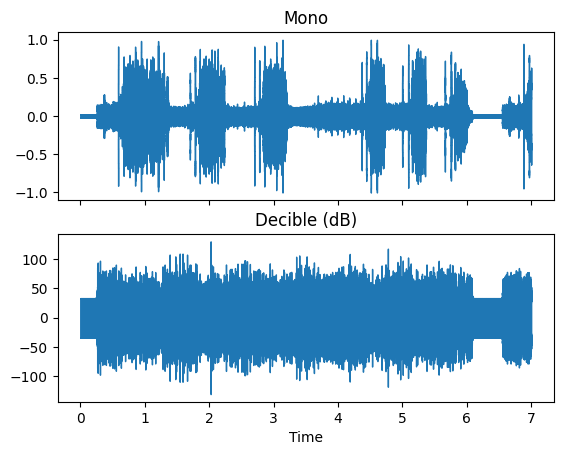

In [3]:

import matplotlib.pyplot as plt
import librosa.display

fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
# plt.figure()
# plt.subplot(3, 1, 2)
librosa.display.waveshow(y=data, sr=sr, ax=ax[0])
librosa.display.waveshow(y=20*np.log10(np.abs(data)), sr=sr, ax=ax[1])
ax[0].set(title='Mono')
ax[0].label_outer()
ax[1].set(title='Decible (dB)')
ax[0].label_outer()


## Plot sound wave spectrogram

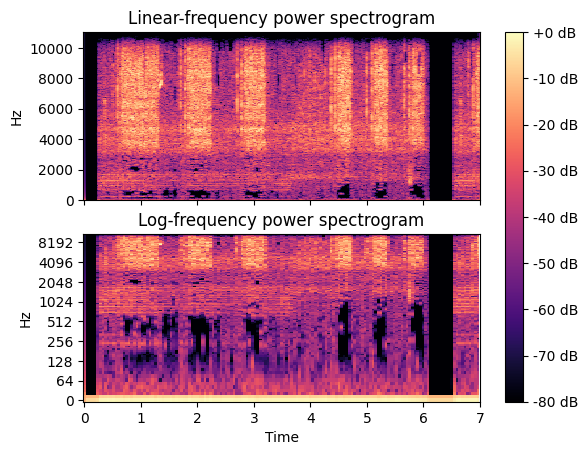

In [4]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
D = librosa.amplitude_to_db(np.abs(librosa.stft(data)), ref=np.max)
img = librosa.display.specshow(D, y_axis='linear', x_axis='time',
                               sr=sr, ax=ax[0])
ax[0].set(title='Linear-frequency power spectrogram')
ax[0].label_outer()

hop_length = 1024
D = librosa.amplitude_to_db(np.abs(librosa.stft(data, hop_length=hop_length)),
                            ref=np.max)
librosa.display.specshow(D, y_axis='log', sr=sr, hop_length=hop_length,
                         x_axis='time', ax=ax[1])
ax[1].set(title='Log-frequency power spectrogram')
ax[1].label_outer()
fig.colorbar(img, ax=ax, format="%+2.f dB")

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

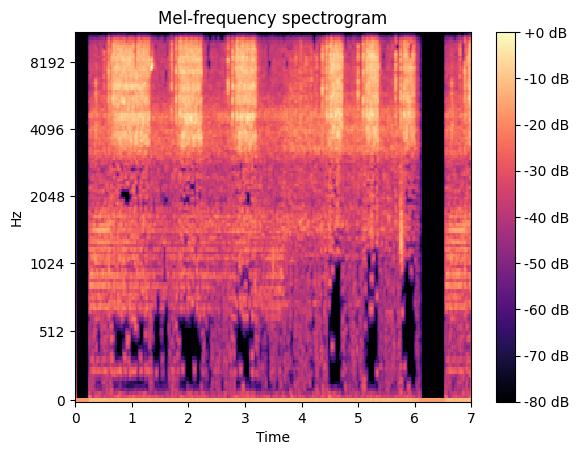

In [5]:
F_MAX = sr // 2
S = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128, fmax=F_MAX)

fig, ax = plt.subplots()
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel', sr=sr, fmax=F_MAX, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

## Manual scalogram plot

In [4]:
sys.path.insert(0, os.path.abspath('..'))
from dataprocess.cwt import plot_scalogram, cwt2, cwt3

plot_scalogram(data, sr)

ModuleNotFoundError: No module named 'util'

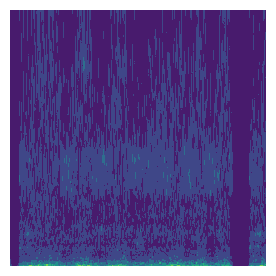

In [8]:

plot_scalogram(data, sr, db=True)

size of x: 308700, memory of x 1234800
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.8159

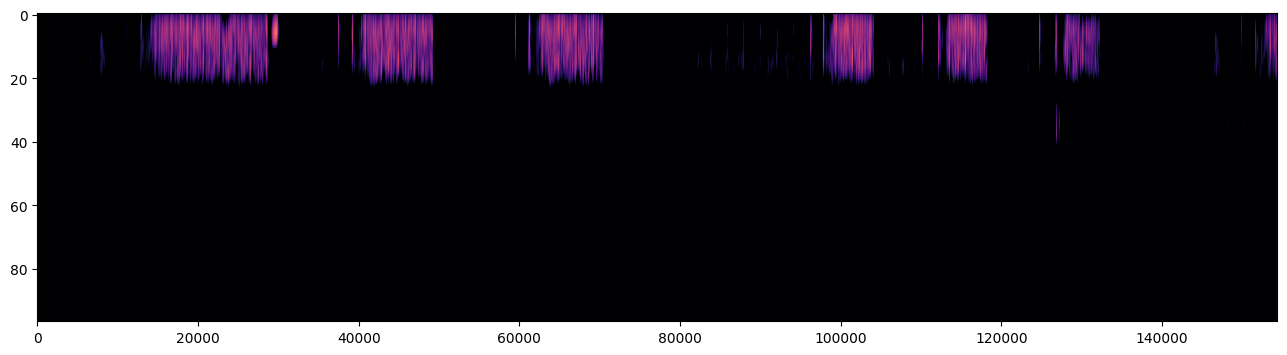

In [9]:
CMAP = 'magma'

cs1, f1 = cwt2(data, nv=12, sr=sr, low_freq=40)
print(f'shape of cs1: {cs1.shape}')
print(f'cs1:\n{cs1[10][52000:52020]}')
print(f'shape of f1: {f1.shape}')
plt.figure(figsize = (16,4))
plt.imshow(20*np.log10(np.abs(cs1)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-30)
plt.show()

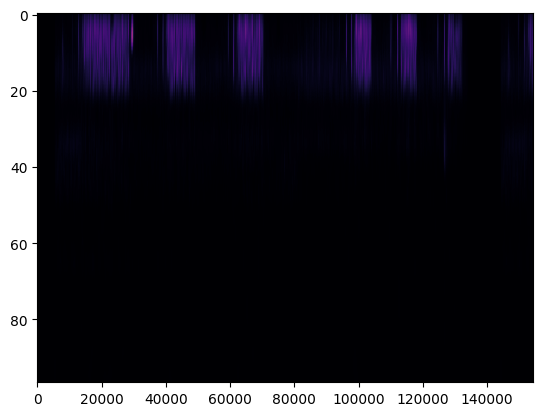

In [10]:
plt.imshow(np.abs(cs1), cmap=CMAP, aspect='auto', norm=None)
plt.show()

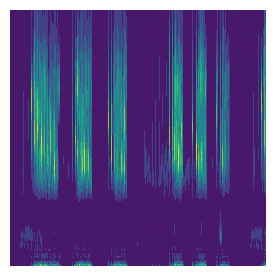

In [11]:
plot_scalogram(data, sr, wavename='cmor3.0-1.0')

## another grasshopper

In [12]:
wav_fn  = f'{SOUND_FOLDER}/gh-4_mono_denoised_filter.wav'
data, sr, TIME, N = load_wave(wav_fn)
IPython.display.Audio(data=data, rate=sr)

[INFO] 2022-10-19 17:33:39,115 - data shape: (228217,)
[INFO] 2022-10-19 17:33:39,116 - data type: float32
[INFO] 2022-10-19 17:33:39,116 - sr: 22050
[DEBUG] 2022-10-19 17:33:39,116 - sound duration: 10.349977324263039
[DEBUG] 2022-10-19 17:33:39,116 - sound fix duration: 10
[INFO] 2022-10-19 17:33:39,116 - N is 220500


[ 0.0000000e+00  0.0000000e+00  3.0517578e-05  6.1035156e-05
  3.0517578e-05  0.0000000e+00 -3.0517578e-05 -6.1035156e-05
 -6.1035156e-05  0.0000000e+00  9.1552734e-05  6.1035156e-05
  0.0000000e+00  0.0000000e+00 -6.1035156e-05 -6.1035156e-05
 -3.0517578e-05  3.0517578e-05  3.0517578e-05  3.0517578e-05]
[-0.0436671  -0.0436671  -0.04343848 -0.04320985 -0.04343848 -0.0436671
 -0.04389572 -0.04412435 -0.04412435 -0.0436671  -0.04298123 -0.04320985
 -0.0436671  -0.0436671  -0.04412435 -0.04412435 -0.04389572 -0.04343848
 -0.04343848 -0.04343848]


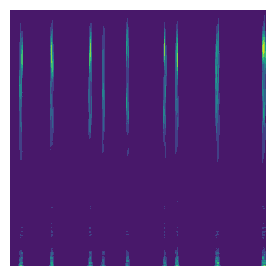

In [13]:
plot_scalogram(data, sr)

size of x: 396900, memory of x 1587600
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.8159

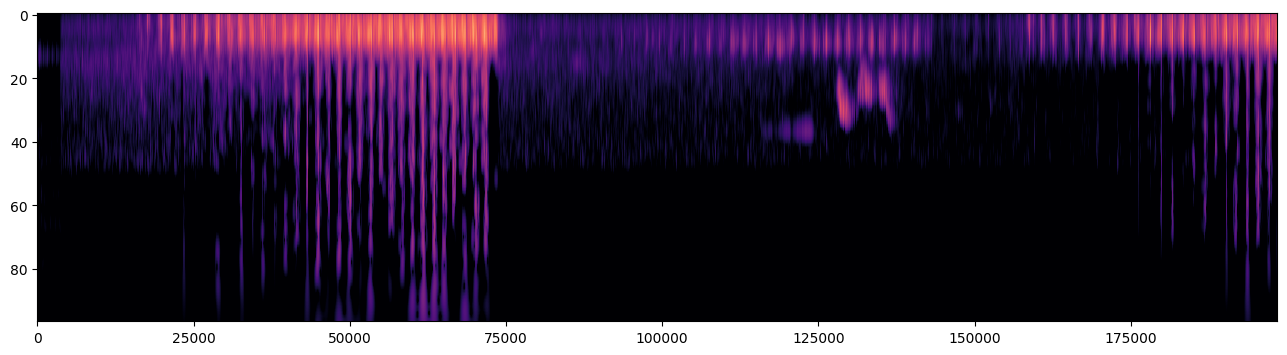

In [16]:
cs4, f4 = cwt3(data, nv=12, sr=sr, low_freq=40)
plt.figure(figsize = (16,4))
plt.imshow(20*np.log10(np.abs(cs4)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-60)
plt.show()

In [14]:
wav_fn2  = f'{SOUND_FOLDER}/gh-2.wav'
data, sr, TIME, N = load_wave(wav_fn2)
IPython.display.Audio(data=data, rate=sr)

[INFO] 2022-10-19 17:33:55,272 - data shape: (217499,)
[INFO] 2022-10-19 17:33:55,272 - data type: float32
[INFO] 2022-10-19 17:33:55,273 - sr: 22050
[DEBUG] 2022-10-19 17:33:55,273 - sound duration: 9.86390022675737
[DEBUG] 2022-10-19 17:33:55,273 - sound fix duration: 9
[INFO] 2022-10-19 17:33:55,273 - N is 198450


[ 0.00291999  0.00036749 -0.00051794  0.00284899  0.0021038   0.0025918
  0.0008273  -0.00026795  0.00289488  0.00205396  0.00154049  0.00019216
  0.0003697   0.0033542   0.00195121 -0.00021067 -0.0006294   0.00070928
  0.00064513 -0.00081898]
[0.0260815  0.02304993 0.02199831 0.02599718 0.02511212 0.02569172
 0.02359604 0.02229522 0.02605168 0.02505293 0.02444309 0.02284169
 0.02305255 0.02659722 0.0249309  0.02236325 0.02186593 0.02345587
 0.02337968 0.02164077]


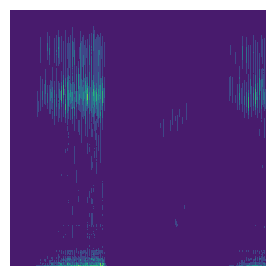

In [14]:
plot_scalogram(data, sr)
